In [1]:
!git clone https://github.com/eklavyakiit/Financial-News-Sentiment-vs-NIFTY50-Analysis.git
%cd Financial-News-Sentiment-vs-NIFTY50-Analysis/data

Cloning into 'Financial-News-Sentiment-vs-NIFTY50-Analysis'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 3.98 MiB | 4.56 MiB/s, done.
/content/Financial-News-Sentiment-vs-NIFTY50-Analysis/data


In [2]:
!pwd
!ls

/content/Financial-News-Sentiment-vs-NIFTY50-Analysis/data
final_project_dataset.csv  news.csv  nifty50.csv


In [3]:
import pandas as pd

news = pd.read_csv("news.csv", encoding='latin1')

In [4]:
print(news.columns)

Index(['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'],
      dtype='object', length=189)


In [5]:
news = news.drop(columns=['Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 179', 'Unnamed: 180',
       'Unnamed: 181', 'Unnamed: 182', 'Unnamed: 183', 'Unnamed: 184',
       'Unnamed: 185', 'Unnamed: 186', 'Unnamed: 187', 'Unnamed: 188'])

In [6]:
print(news.columns.tolist())
print(news.shape)

['Title', 'Date', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnamed: 66', 'Unnamed: 67', 'Unnamed: 68', 'Unnamed: 69', 'Unnamed: 70', 'Unnamed: 71', 'Unnamed: 72', 'Unnamed: 73', 'Unnamed: 74', 'Unname

In [7]:
news = news.iloc[:, :2]

In [8]:
print(news.columns.tolist())
print(news.shape)

['Title', 'Date']
(3349, 2)


In [9]:
print(news.columns)
print(news.isnull().sum())

Index(['Title', 'Date'], dtype='object')
Title    0
Date     0
dtype: int64


In [10]:
news = news.dropna()
news = news.drop_duplicates()
news['Title'] = news['Title'].str.strip()

In [11]:
print(news.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3348 entries, 0 to 3348
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3348 non-null   object
 1   Date    3348 non-null   object
dtypes: object(2)
memory usage: 78.5+ KB
None


In [12]:
grouped_news = (news.groupby("Date")["Title"].apply(list).reset_index())

In [13]:
print(grouped_news.head())
print(grouped_news.shape)

                                                Date  \
0   just some time back that you resisted going t...   
1                                         01-04-2025   
2                                         01-05-2025   
3                                         01-06-2025   
4                                         01-07-2025   

                                               Title  
0    [ur. You're always in a t-shirt. Like you said]  
1  [Indian companies gear up for nuclear expansio...  
2  [Adani Enterprises Q4 Results: Net profit rise...  
3  [Trade Spotlight: How should you trade CDSL, M...  
4  [PSU bank stocks snap 5-day gaining streak ami...  
(174, 2)


In [14]:
grouped_news = grouped_news.iloc[1:]

In [15]:
print(grouped_news.head())
print(grouped_news.shape)

         Date                                              Title
1  01-04-2025  [Indian companies gear up for nuclear expansio...
2  01-05-2025  [Adani Enterprises Q4 Results: Net profit rise...
3  01-06-2025  [Trade Spotlight: How should you trade CDSL, M...
4  01-07-2025  [PSU bank stocks snap 5-day gaining streak ami...
5  01-08-2025  [ITC share price gain 1.27% in friday's tradin...
(173, 2)


In [16]:
grouped_news['Date'] = pd.to_datetime(
    grouped_news['Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [17]:
print(grouped_news['Date'].head())
print(grouped_news['Date'].dtype)
print(grouped_news['Date'].isnull().sum())

1   2025-04-01
2   2025-05-01
3   2025-06-01
4   2025-07-01
5   2025-08-01
Name: Date, dtype: datetime64[ns]
datetime64[ns]
0


In [18]:
grouped_news.to_csv("grouped_news.csv", index=False)

In [19]:
stock = pd.read_csv("nifty50.csv", encoding='cp1252')
print(stock.columns)
print(stock.head())

Index(['ï»¿Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (â‚¹ Cr)'],
      dtype='object')
      ï»¿Date      Open      High       Low     Close   Shares Traded   \
0  29-AUG-2025  24466.70  24572.45  24404.70  24426.85       325543583   
1  28-AUG-2025  24695.80  24702.65  24481.60  24500.90       326601486   
2  26-AUG-2025  24899.50  24919.65  24689.60  24712.05       750473927   
3  25-AUG-2025  24949.15  25021.55  24894.35  24967.75       213032133   
4  22-AUG-2025  25064.15  25084.85  24859.15  24870.10       210165384   

   Turnover (â‚¹ Cr)  
0           26796.69  
1           29371.67  
2           47068.20  
3           19871.25  
4           19655.78  


In [20]:
stock.columns = [
    'date',
    'open',
    'high',
    'low',
    'close',
    'shares_traded',
    'turnover_cr'
]

In [21]:
print(stock.columns)
print(stock.head())

Index(['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr'], dtype='object')
          date      open      high       low     close  shares_traded  \
0  29-AUG-2025  24466.70  24572.45  24404.70  24426.85      325543583   
1  28-AUG-2025  24695.80  24702.65  24481.60  24500.90      326601486   
2  26-AUG-2025  24899.50  24919.65  24689.60  24712.05      750473927   
3  25-AUG-2025  24949.15  25021.55  24894.35  24967.75      213032133   
4  22-AUG-2025  25064.15  25084.85  24859.15  24870.10      210165384   

   turnover_cr  
0     26796.69  
1     29371.67  
2     47068.20  
3     19871.25  
4     19655.78  


In [22]:
stock['shares_traded'] = stock['shares_traded'].astype(float)
stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')

/tmp/ipykernel_1727/1002184138.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')


In [23]:
print(stock.dtypes)
print(stock['date'].head())
print(stock['date'].isnull().sum())

date             datetime64[ns]
open                    float64
high                    float64
low                     float64
close                   float64
shares_traded           float64
turnover_cr             float64
dtype: object
0   2025-08-29
1   2025-08-28
2   2025-08-26
3   2025-08-25
4   2025-08-22
Name: date, dtype: datetime64[ns]
0


In [24]:
merged = pd.merge(stock, grouped_news, left_on='date', right_on='Date', how='inner')

In [25]:
print(merged.isnull().sum())
print(merged.shape)
print(merged.head())

date             0
open             0
high             0
low              0
close            0
shares_traded    0
turnover_cr      0
Date             0
Title            0
dtype: int64
(132, 9)
        date      open      high       low     close  shares_traded  \
0 2025-08-21  25142.00  25153.65  25054.90  25083.75    226542052.0   
1 2025-08-20  24965.80  25088.70  24929.70  25050.55    287054119.0   
2 2025-08-19  24891.35  25012.65  24873.95  24980.65    252340828.0   
3 2025-08-18  24938.20  25022.00  24852.85  24876.95    363071305.0   
4 2025-08-14  24607.25  24673.65  24596.90  24631.30    270162203.0   

   turnover_cr       Date                                              Title  
0     21865.07 2025-08-21  [Stocks to Watch Today: Clean Science, Shanti ...  
1     25330.45 2025-08-20  [KPR Mill shares rise 2.09% in Wednesday's ses...  
2     24781.97 2025-08-19  [Kalyan Jewellers India shares decline 2.45% a...  
3     37637.67 2025-08-18  [BSE, HDFC AMC, MCX, other capital ma

In [26]:
merged['movement'] = merged['close'] - merged['open']

def check_movement(x):
    if x > 0:
        return 1
    else:
        return 0

merged['target'] = merged['movement'].apply(check_movement)

In [27]:
print(merged[['date', 'open', 'close', 'movement', 'target']].head(10))
print(merged['target'].value_counts())

        date      open     close  movement  target
0 2025-08-21  25142.00  25083.75    -58.25       0
1 2025-08-20  24965.80  25050.55     84.75       1
2 2025-08-19  24891.35  24980.65     89.30       1
3 2025-08-18  24938.20  24876.95    -61.25       0
4 2025-08-14  24607.25  24631.30     24.05       1
5 2025-08-13  24586.20  24619.35     33.15       1
6 2025-08-12  24563.35  24487.40    -75.95       0
7 2025-08-11  24371.50  24585.05    213.55       1
8 2025-08-08  24544.25  24363.30   -180.95       0
9 2025-08-07  24464.20  24596.15    131.95       1
target
0    67
1    65
Name: count, dtype: int64


### Sentiment Scoring Approach

I built a rule-based sentiment scorer using two hand-curated word lists (~59 positive, 53 negative financial terms), rather than an NLP library, so I could understand exactly how the score is calculated. The score is a simple count: +1 for each positive word match, -1 for each negative word match, summed across that day's headlines. It's an unbounded score, not normalized - a day with more headlines can produce a larger-magnitude score purely from volume, not necessarily stronger sentiment.

In [28]:
positive_words = [
    'gain', 'gains', 'gained', 'gainers', 'gainer',
    'growth', 'grew', 'grow', 'growing',
    'profit', 'profitable', 'profitability', 'profits',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'bullish', 'bull', 'bull run',
    'record', 'record-high', 'all-time high', 'peak',
    'upgrade', 'upgraded', 'upgrades',
    'buyback', 'share buyback', 'repurchase',
    'guidance raised', 'guidance upgrade',
    'loan growth', 'credit growth', 'deposit growth',
    'oversubscribed', 'oversubscription',
    'multibagger', 'broad-based rally',
    'jump', 'jumps', 'jumped', 'soar', 'soars', 'soared',
    'strong', 'strength', 'beat', 'beats', 'outperform'
]

negative_words = [
    'loss', 'losses', 'lost', 'lose', 'losing',
    'decline', 'declines', 'declined', 'declining',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plummet', 'nosedive', 'collapse',
    'bearish', 'bear market',
    'downgrade', 'downgraded', 'downgrades',
    'recession', 'stagflation', 'slowdown',
    'layoffs', 'retrenchment', 'downsizing',
    'default', 'bankruptcy', 'insolvency',
    'npa', 'bad loan', 'write-off',
    'rate hike', 'hawkish', 'monetary tightening',
    'fii selling', 'dii selling', 'institutional selling',
    'circuit breaker', 'lower circuit',
    'fall', 'falls', 'fell', 'drop', 'drops', 'dropped',
    'weak', 'weakness', 'miss', 'misses', 'underperform'
]

In [29]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0
    for word in positive_words:
        score += text.count(word)
    for word in negative_words:
        score -= text.count(word)
    return score

merged['sentiment_score'] = merged['Title'].apply(sentiment_score)

**Note:** `merged['Title']` holds a Python list of headlines per day, not a single string. `str(text)` converts the whole list - including brackets and quotes - into one string before scoring. This still works correctly because `.count()` searches for substrings anywhere in that text, but it means the scorer is technically working on "messier" text than clean joined headlines would be.

In [30]:
print(merged[['date', 'Title', 'sentiment_score']].head(10))
print(merged['sentiment_score'].describe())

        date                                              Title  \
0 2025-08-21  [Stocks to Watch Today: Clean Science, Shanti ...   
1 2025-08-20  [KPR Mill shares rise 2.09% in Wednesday's ses...   
2 2025-08-19  [Kalyan Jewellers India shares decline 2.45% a...   
3 2025-08-18  [BSE, HDFC AMC, MCX, other capital market stoc...   
4 2025-08-14  [Lux Industries Standalone June 2025 Net Sales...   
5 2025-08-13  [Broking stocks higher as Sebi consultation pa...   
6 2025-08-12  [Aurobindo Pharm Consolidated June 2025 Net Sa...   
7 2025-08-11  [Lupin launches Glucagon injection, targets $1...   
8 2025-08-08  [Trade Spotlight: How should you trade TVS Mot...   
9 2025-08-07  [TCS to roll out wage hikes after announcing p...   

   sentiment_score  
0                4  
1                6  
2                6  
3               14  
4                6  
5                5  
6               10  
7               10  
8              -19  
9              -24  
count    132.000000
mean       

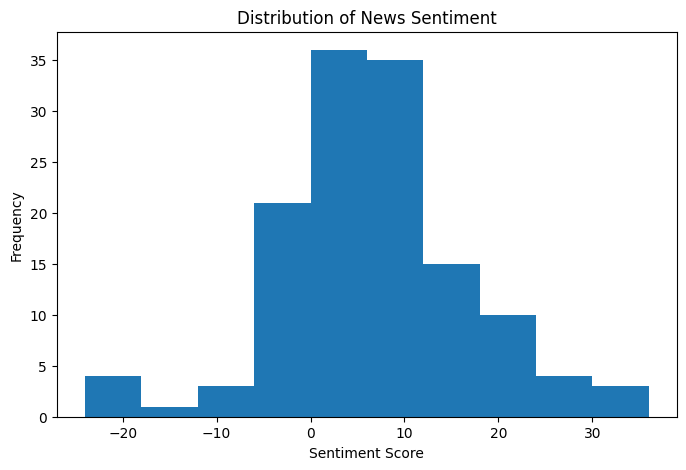

In [31]:
import os
os.makedirs("plots", exist_ok=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(merged['sentiment_score'])
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment")
plt.savefig("plots/histogram.png", dpi=300, bbox_inches='tight')
plt.show()

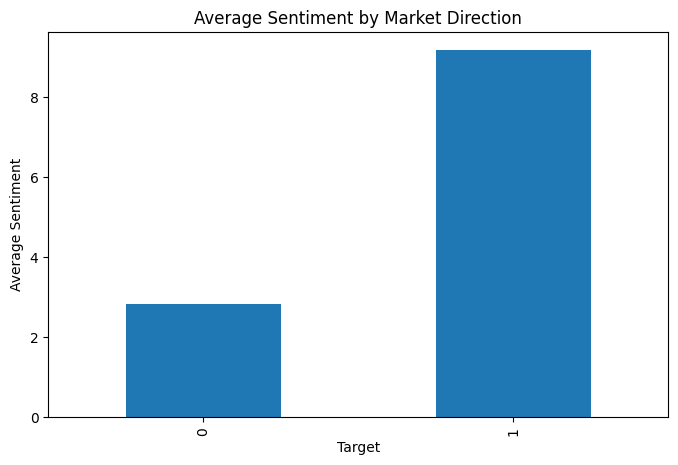

In [32]:
plt.figure(figsize=(8,5))
merged.groupby('target')['sentiment_score'].mean().plot(kind='bar')
plt.xlabel("Target")
plt.ylabel("Average Sentiment")
plt.title("Average Sentiment by Market Direction")
plt.savefig("plots/barplot.png", dpi=300, bbox_inches='tight')
plt.show()

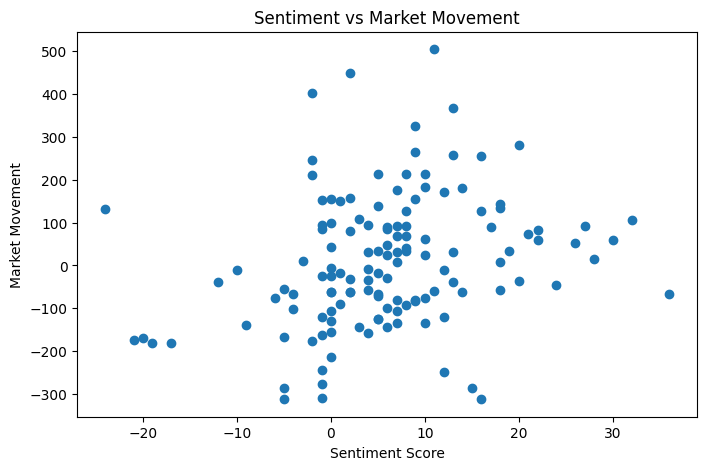

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(merged['sentiment_score'], merged['movement'])
plt.xlabel("Sentiment Score")
plt.ylabel("Market Movement")
plt.title("Sentiment vs Market Movement")
plt.savefig("plots/scatterplot.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
def predict_market(score):
    if score > 0:
        return "UP"
    elif score < 0:
        return "DOWN"
    else:
        return "NEUTRAL"

merged['prediction'] = merged['sentiment_score'].apply(predict_market)
print(merged[['date', 'sentiment_score', 'prediction']].head())

        date  sentiment_score prediction
0 2025-08-21                4         UP
1 2025-08-20                6         UP
2 2025-08-19                6         UP
3 2025-08-18               14         UP
4 2025-08-14                6         UP


In [35]:
def binary_prediction(score):
    if score > 0:
        return 1
    return 0

merged['prediction_binary'] = merged['sentiment_score'].apply(binary_prediction)

In [36]:
accuracy = (merged['prediction_binary'] == merged['target']).mean()
print("Prediction Accuracy:", round(accuracy*100, 2), "%")

majority_baseline = (merged['target'] == merged['target'].mode()[0]).mean()
print("Majority-class baseline:", round(majority_baseline*100, 2), "%")

Prediction Accuracy: 62.88 %
Majority-class baseline: 50.76 %


### Interpreting Part A's Accuracy

This accuracy (62.88% vs a 50.76% majority baseline) measures whether today's sentiment score matches today's price direction, not whether sentiment predicts the future. News and price moves often happen on the same day because they share the same cause, for example an earnings report drives both the headline and the price. This is same-day co-movement, not a tradeable prediction. You'd need tomorrow's headlines before today's close to actually use this rule.

In [37]:
merged.to_csv("final_project_dataset.csv", index=False)
print("Final dataset saved successfully.")

Final dataset saved successfully.


In [38]:
part_a_accuracy = accuracy
part_a_baseline = majority_baseline

In [39]:
import pandas as pd
import numpy as np

ml_df = pd.read_csv('final_project_dataset.csv', parse_dates=['date'])
ml_df = ml_df.sort_values('date').reset_index(drop=True)

print(ml_df.shape)
print(ml_df[['date', 'target']].head())

(132, 14)
        date  target
0 2025-02-07       0
1 2025-02-10       0
2 2025-02-11       0
3 2025-02-12       0
4 2025-02-13       0


### Fixing the Leakage: Predicting Tomorrow, Not Today

Part A's rule technically predicted the same day it was scored on, not a real forecast. Here I shift the target forward by one day (shift(-1)), so each row's next_day_target is tomorrow's actual outcome. This turns the task into genuine forecasting: given everything known as of today's close, can we predict tomorrow's direction?

In [40]:
ml_df['next_day_target'] = ml_df['target'].shift(-1)
ml_df = ml_df.dropna(subset=['next_day_target'])
ml_df['next_day_target'] = ml_df['next_day_target'].astype(int)

print(ml_df[['date', 'target', 'next_day_target']].head(10))
print(ml_df.shape)

        date  target  next_day_target
0 2025-02-07       0                0
1 2025-02-10       0                0
2 2025-02-11       0                0
3 2025-02-12       0                0
4 2025-02-13       0                0
5 2025-02-14       0                1
6 2025-02-17       1                0
7 2025-02-18       0                1
8 2025-02-19       1                1
9 2025-02-20       1                0
(131, 15)


In [41]:
ml_df['sentiment_ma3'] = ml_df['sentiment_score'].rolling(3).mean()
ml_df['sentiment_ma7'] = ml_df['sentiment_score'].rolling(7).mean()
ml_df['sentiment_std3'] = ml_df['sentiment_score'].rolling(3).std()

ml_df['movement_lag1'] = ml_df['movement'].shift(1)
ml_df['movement_lag2'] = ml_df['movement'].shift(2)

ml_df['volume_change'] = ml_df['shares_traded'].pct_change()
ml_df['high_low_spread'] = (ml_df['high'] - ml_df['low']) / ml_df['open'] * 100

ml_df = ml_df.dropna().reset_index(drop=True)
print(ml_df.shape)

(125, 22)


In [42]:
feature_cols = ['sentiment_score', 'sentiment_ma3', 'sentiment_ma7', 'sentiment_std3',
                 'movement_lag1', 'movement_lag2', 'volume_change', 'high_low_spread']

X = ml_df[feature_cols]
y = ml_df['next_day_target']

print(X.shape, y.shape)
print(X.head())

(125, 8) (125,)
   sentiment_score  sentiment_ma3  sentiment_ma7  sentiment_std3  \
0                1      -1.333333      -1.285714        3.214550   
1                1      -1.000000      -1.285714        3.464102   
2               -1       0.333333      -1.285714        1.154701   
3                8       2.666667       0.571429        4.725816   
4                2       3.000000       0.857143        4.582576   

   movement_lag1  movement_lag2  volume_change  high_low_spread  
0        -167.20         -24.35      -0.185027         1.090535  
1         149.60        -167.20       0.015539         0.831749  
2         -18.35         149.60      -0.017176         1.029008  
3          85.65         -18.35       0.163467         0.486830  
4          92.05          85.65       0.007961         0.878060  


### Why a Chronological Split, Not a Random One

Financial time series can't be split randomly. A shuffled split would let the model train on days adjacent to, or even after, days in the test set, leaking future information and inflating accuracy in a way that wouldn't hold up in real use. Instead, the first 80% of days (chronologically) are used for training, and the most recent 20% are held out as a genuinely unseen test set.

In [43]:
split_idx = int(len(ml_df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.shape[0]} days | Test: {X_test.shape[0]} days')

Train: 100 days | Test: 25 days


In [44]:
part_b_baseline = (y_test == y_test.mode()[0]).mean()
print('Majority-class baseline (test period):', round(part_b_baseline*100, 2), '%')

Majority-class baseline (test period): 56.0 %


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print('Logistic Regression accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression accuracy: 0.48
              precision    recall  f1-score   support

           0       0.60      0.21      0.32        14
           1       0.45      0.82      0.58        11

    accuracy                           0.48        25
   macro avg       0.53      0.52      0.45        25
weighted avg       0.53      0.48      0.43        25



In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print('Random Forest accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest accuracy: 0.4
              precision    recall  f1-score   support

           0       0.44      0.29      0.35        14
           1       0.38      0.55      0.44        11

    accuracy                           0.40        25
   macro avg       0.41      0.42      0.40        25
weighted avg       0.41      0.40      0.39        25



In [47]:
!pip install -q xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print('XGBoost accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost accuracy: 0.36
              precision    recall  f1-score   support

           0       0.38      0.21      0.27        14
           1       0.35      0.55      0.43        11

    accuracy                           0.36        25
   macro avg       0.36      0.38      0.35        25
weighted avg       0.37      0.36      0.34        25



In [48]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)

Best params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 300}
Best CV accuracy: 0.5375


In [49]:
best_rf = grid_search.best_estimator_
tuned_test_accuracy = accuracy_score(y_test, best_rf.predict(X_test))
print('Tuned test accuracy:', tuned_test_accuracy)

Tuned test accuracy: 0.44


### Backtest Caveat

This backtest ignores transaction costs, slippage, and taxes, and uses a very small test window (25 days). It's an illustrative exercise, not a trading signal. Given the model accuracies were at or below the majority baseline, this chart should not be read as evidence of a viable strategy.

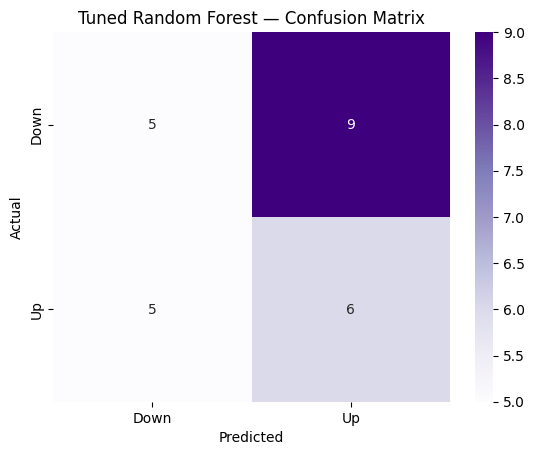

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Tuned Random Forest — Confusion Matrix')
plt.show()

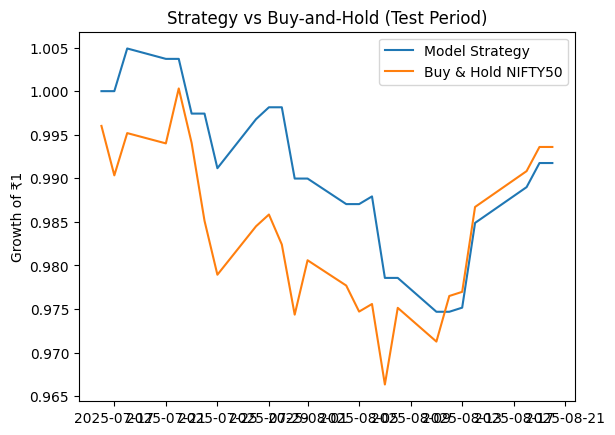

In [51]:
test_df = ml_df.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = best_rf.predict(X_test)

test_df['next_day_return_pct'] = (test_df['close'].shift(-1) - test_df['close']) / test_df['close'] * 100
test_df['strategy_return'] = np.where(test_df['pred'] == 1, test_df['next_day_return_pct'], 0)

test_df['cumulative_strategy'] = (1 + test_df['strategy_return'].fillna(0)/100).cumprod()
test_df['cumulative_market'] = (1 + test_df['next_day_return_pct'].fillna(0)/100).cumprod()

plt.plot(test_df['date'], test_df['cumulative_strategy'], label='Model Strategy')
plt.plot(test_df['date'], test_df['cumulative_market'], label='Buy & Hold NIFTY50')
plt.legend(); plt.title('Strategy vs Buy-and-Hold (Test Period)')
plt.ylabel('Growth of ₹1'); plt.show()

### What Actually Mattered

This directly answers the project's core question: does sentiment help explain market movement? The feature importance ranking shows pure price-history and volatility features (high_low_spread, movement_lag1) ranked above all sentiment features. Among the sentiment features themselves, the smoothed 7-day rolling average outranked the raw daily score, suggesting any sentiment signal that exists is in the trend, not any single day's headlines. Combined with the sub-baseline model accuracies, this indicates sentiment carries a weak, inconsistent signal that price history explains better.

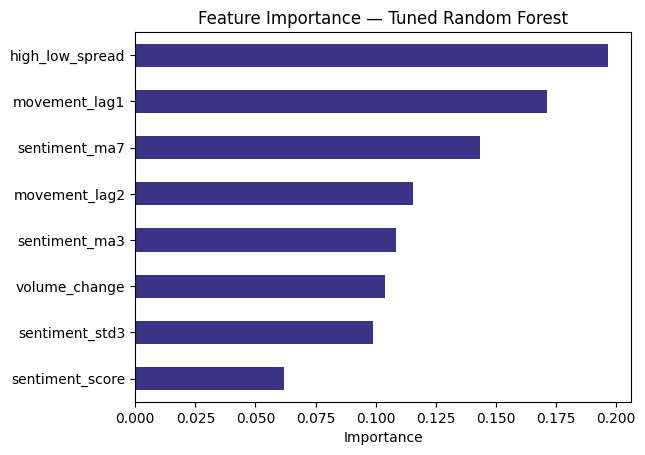

In [52]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', color='#3B3486')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')
plt.show()

In [53]:
print(len(positive_words), len(negative_words))
print(merged['sentiment_score'].describe())
print("Part A Accuracy:", round(part_a_accuracy*100, 2), "%")
print("Part A Baseline:", round(part_a_baseline*100, 2), "%")

59 53
count    132.000000
mean       5.962121
std       10.098300
min      -24.000000
25%        0.000000
50%        6.000000
75%       11.000000
max       36.000000
Name: sentiment_score, dtype: float64
Part A Accuracy: 62.88 %
Part A Baseline: 50.76 %


In [54]:
print(ml_df['sentiment_score'].describe())

count    125.000000
mean       6.344000
std       10.220239
min      -24.000000
25%        0.000000
50%        6.000000
75%       12.000000
max       36.000000
Name: sentiment_score, dtype: float64


In [55]:
def sentiment_score_v2(text_list):
    joined = ' '.join(text_list).lower()
    score = 0
    for word in positive_words:
        score += joined.count(word)
    for word in negative_words:
        score -= joined.count(word)
    return score

merged['sentiment_score_v2'] = merged['Title'].apply(sentiment_score_v2)

print(merged[['sentiment_score', 'sentiment_score_v2']].describe())
print((merged['sentiment_score'] == merged['sentiment_score_v2']).mean())

       sentiment_score  sentiment_score_v2
count       132.000000          132.000000
mean          5.962121            5.962121
std          10.098300           10.098300
min         -24.000000          -24.000000
25%           0.000000            0.000000
50%           6.000000            6.000000
75%          11.000000           11.000000
max          36.000000           36.000000
1.0


### Stretch Goal: Does Text Formatting Matter?

I tested whether scoring the raw stringified list (with brackets and quotes) versus properly joined plain text changes the sentiment scores. They are identical for all 132 days. This confirms that .count() finding substrings anywhere in the text made the formatting artifacts (commas, brackets, quotes) irrelevant to the scoring, since none of the word-list terms happen to span across those characters. The original scoring approach was safe to use as is.

### Word List Size Experiment

I also tested an expanded version of these word lists (140 positive, 145 negative terms covering more finance-specific vocabulary) before settling on the smaller list used above. The expanded version reduced Part A accuracy from 62.88% to 57.58%, and reduced every Part B model's test accuracy as well (for example, tuned Random Forest test accuracy dropped from 44% to 36%). I reverted to the smaller list since it performed better across the board, a result worth noting since it suggests a broader but noisier vocabulary can hurt performance on a small dataset like this one, rather than help it.